# Advanced Tourist Arrival Forecasting

This notebook leaves `main.ipynb` unchanged and tests advanced ensemble regressors. Model settings are selected using only the 2023 validation set; 2024 remains an untouched final test set.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load data and create a time-safe lag feature

`arrivals_same_month_last_year` uses the observed count for the same country and month one year earlier. It is constructed by an exact key-based merge, so a missing month cannot accidentally shift the sequence.

In [2]:
df = pd.read_csv('touristData.csv')

previous_year = df[['year', 'month', 'originCountry', 'totalCount']].copy()
previous_year['year'] = previous_year['year'] + 1
previous_year = previous_year.rename(
    columns={'totalCount': 'arrivals_same_month_last_year'}
)

model_df = df.merge(
    previous_year,
    on=['year', 'month', 'originCountry'],
    how='left',
    validate='one_to_one'
)

print('Original rows:', len(df))
print('Rows with a previous-year target:', model_df['arrivals_same_month_last_year'].notna().sum())
model_df.groupby('year')['arrivals_same_month_last_year'].agg(['count', 'size'])

Original rows: 750
Rows with a previous-year target: 434


,count,size
year,,
2018,0,120
2019,107,120
2020,25,30
2021,19,120
2022,87,120
2023,94,120
2024,102,120


## 2. Chronological split and preprocessing

Training uses observations through 2022, validation uses 2023, and testing uses 2024. Rows without an exact previous-year observation are retained: the numeric median imputer fills the missing lag values without using validation or test information.

In [3]:
target = 'totalCount'
categorical_features = ['month', 'originCountry']
feature_columns = [
    col for col in model_df.columns
    if col != target
]
numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

X = model_df[feature_columns].copy()
y = model_df[target].copy()

train_mask = model_df['year'] <= 2022
validation_mask = model_df['year'] == 2023
test_mask = model_df['year'] == 2024

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[validation_mask], y.loc[validation_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows': [len(X_train), len(X_val), len(X_test)],
    'Target mean': [y_train.mean(), y_val.mean(), y_test.mean()]
})

,Split,Rows,Target mean
0,Train,510,7780.684314
1,Validation,120,8899.733333
2,Test,120,11916.366667


## 3. Validation-based model tuning

Ridge is included as a regularized baseline. Random Forest, Extra Trees, and Histogram Gradient Boosting can learn nonlinear relationships and interactions. The small grids keep this experiment reproducible and reasonably fast.

In [4]:
def regression_metrics(y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    return {
        'MAE': mean_absolute_error(y_true, predictions),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2 Score': r2_score(y_true, predictions)
    }

model_search = {
    'Ridge': (
        Ridge(),
        {'alpha': [1.0, 10.0, 100.0]}
    ),
    'Random Forest': (
        RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
        {'max_depth': [None, 10], 'min_samples_leaf': [1, 3]}
    ),
    'Extra Trees': (
        ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
        {'max_depth': [None, 10], 'min_samples_leaf': [1, 3]}
    ),
    'Histogram Gradient Boosting': (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=False),
        {
            'learning_rate': [0.03, 0.08],
            'max_leaf_nodes': [15, 31],
            'l2_regularization': [0.0, 1.0]
        }
    )
}

In [5]:
validation_rows = []
best_models = {}
best_parameters = {}

for model_name, (estimator, parameter_grid) in model_search.items():
    best_rmse = np.inf

    for parameters in ParameterGrid(parameter_grid):
        candidate_estimator = clone(estimator).set_params(**parameters)
        candidate = Pipeline([
            ('preprocessor', preprocessor),
            ('model', candidate_estimator)
        ])
        candidate.fit(X_train, y_train)
        predictions = candidate.predict(X_val)
        scores = regression_metrics(y_val, predictions)
        validation_rows.append({
            'Model': model_name,
            'Parameters': parameters,
            **scores
        })

        if scores['RMSE'] < best_rmse:
            best_rmse = scores['RMSE']
            best_models[model_name] = candidate
            best_parameters[model_name] = parameters.copy()

validation_search_results = pd.DataFrame(validation_rows).sort_values('RMSE')
validation_search_results.head(10)

,Model,Parameters,MAE,MSE,RMSE,R2 Score
3,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1}",4258.719458,5.175633e+07,7194.187536,0.177785
5,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1}",4374.407659,5.353648e+07,7316.863007,0.149505
17,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",4688.506069,5.800436e+07,7616.059445,0.078527
6,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 3}",4561.871499,5.864731e+07,7658.153034,0.068313
16,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",4741.226918,5.872171e+07,7663.009449,0.067131
14,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",4873.115561,5.913453e+07,7689.897971,0.060573
4,Random Forest,"{'max_depth': None, 'min_samples_leaf': 3}",4579.157438,5.917428e+07,7692.482338,0.059942
18,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",4807.803132,5.921117e+07,7694.879767,0.059356
13,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",5008.879786,5.998017e+07,7744.686499,0.047139
12,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",4848.148501,6.057105e+07,7782.740458,0.037752


## 4. Final comparison

Each model family contributes only its validation-selected configuration. Test metrics are reported after selection and are not used for tuning.

In [6]:
comparison_rows = []

for model_name, model in best_models.items():
    for split_name, X_eval, y_eval in [
        ('Validation 2023', X_val, y_val),
        ('Test 2024', X_test, y_test)
    ]:
        predictions = model.predict(X_eval)
        comparison_rows.append({
            'Model': model_name,
            'Split': split_name,
            'Selected Parameters': best_parameters[model_name],
            **regression_metrics(y_eval, predictions)
        })

results = (
    pd.DataFrame(comparison_rows)
    .set_index(['Model', 'Split'])
    .sort_values(['Split', 'RMSE'])
)
results

,,Selected Parameters,MAE,MSE,RMSE,R2 Score
Model,Split,,,,,
Ridge,Test 2024,{'alpha': 1.0},6287.410107,6.838558e+07,8269.557279,0.314533
Histogram Gradient Boosting,Test 2024,"{'l2_regularization': 1.0, 'learning_rate': 0....",6877.943834,1.025664e+08,10127.508942,-0.028080
Random Forest,Test 2024,"{'max_depth': None, 'min_samples_leaf': 1}",6928.512104,1.064730e+08,10318.575119,-0.067238
Extra Trees,Test 2024,"{'max_depth': None, 'min_samples_leaf': 1}",8384.219479,1.418967e+08,11912.039455,-0.422309
Random Forest,Validation 2023,"{'max_depth': None, 'min_samples_leaf': 1}",4258.719458,5.175633e+07,7194.187536,0.177785
Histogram Gradient Boosting,Validation 2023,"{'l2_regularization': 1.0, 'learning_rate': 0....",4688.506069,5.800436e+07,7616.059445,0.078527
Extra Trees,Validation 2023,"{'max_depth': None, 'min_samples_leaf': 1}",5346.081896,6.821351e+07,8259.146977,-0.083658
Ridge,Validation 2023,{'alpha': 1.0},6664.192508,7.041566e+07,8391.403668,-0.118642


## 5. Inspect the validation-selected winner

The winning family is selected by validation RMSE, not by its test score. The plots then show its untouched 2024 performance.

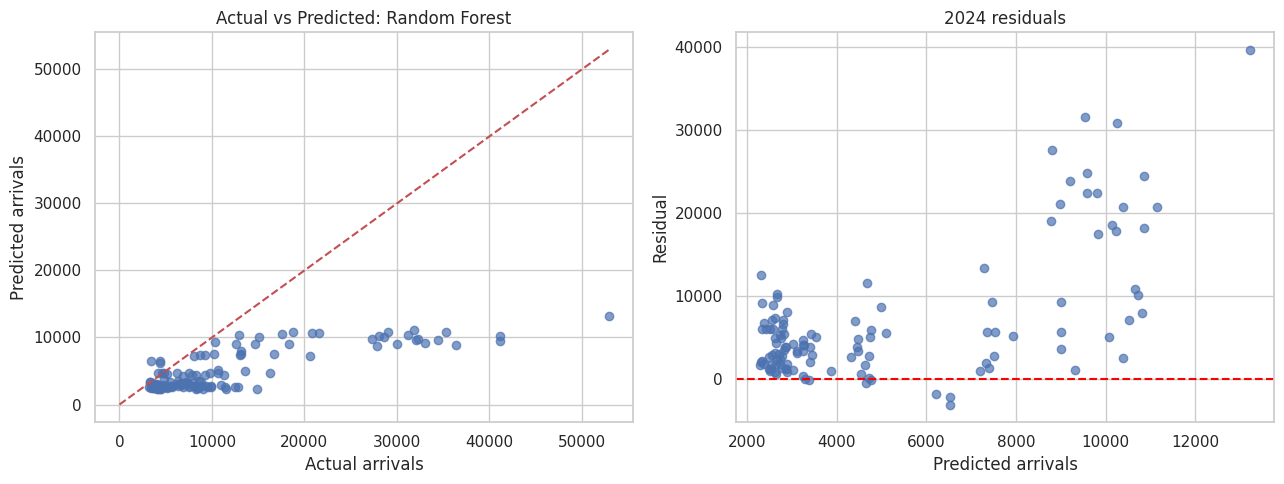

Validation-selected winner: Random Forest
Parameters: {'max_depth': None, 'min_samples_leaf': 1}


In [7]:
validation_summary = results.xs('Validation 2023', level='Split')
winner_name = validation_summary['RMSE'].idxmin()
winner = best_models[winner_name]
test_predictions = winner.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, test_predictions, alpha=0.7)
limit = max(y_test.max(), test_predictions.max())
axes[0].plot([0, limit], [0, limit], 'r--')
axes[0].set_title(f'Actual vs Predicted: {winner_name}')
axes[0].set_xlabel('Actual arrivals')
axes[0].set_ylabel('Predicted arrivals')

residuals = y_test - test_predictions
axes[1].scatter(test_predictions, residuals, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('2024 residuals')
axes[1].set_xlabel('Predicted arrivals')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()
print('Validation-selected winner:', winner_name)
print('Parameters:', best_parameters[winner_name])

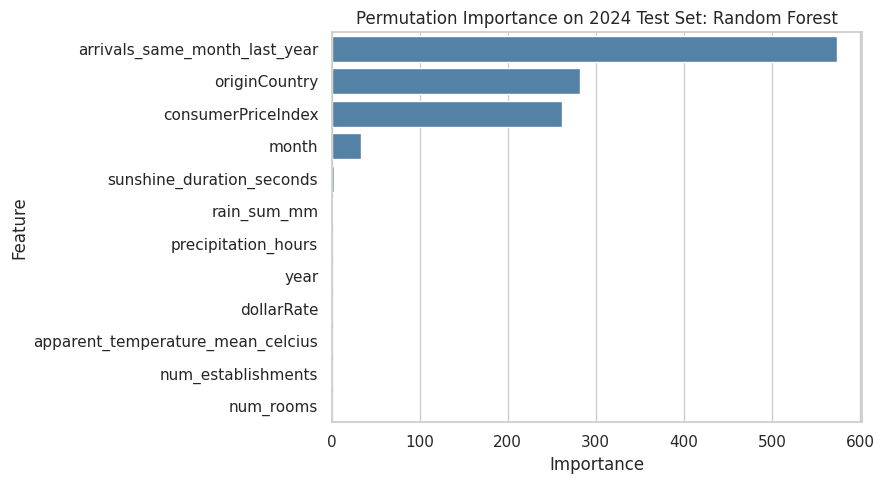

,Feature,Importance
12,arrivals_same_month_last_year,573.395137
2,originCountry,281.971903
11,consumerPriceIndex,262.007920
1,month,33.982042
5,sunshine_duration_seconds,2.880582
6,rain_sum_mm,1.880025
7,precipitation_hours,0.668735
0,year,0.000000
3,dollarRate,0.000000
4,apparent_temperature_mean_celcius,0.000000


In [8]:
importance = permutation_importance(
    winner,
    X_test,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = (
    pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': importance.importances_mean
    })
    .sort_values('Importance', ascending=False)
    .head(12)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title(f'Permutation Importance on 2024 Test Set: {winner_name}')
plt.tight_layout()
plt.show()
importance_df

## Interpretation notes

- Compare the advanced models with the Linear Regression result in `main.ipynb`.
- A positive 2024 R² and lower RMSE indicate improvement over the mean baseline.
- The lag feature assumes the previous year's count is available, which is appropriate for annual planning but should be stated in the report.
- Results can still be affected by the COVID-era structural break and the small sample size.
- Do not select a model using the 2024 test result; selection has already been performed with 2023 validation data.